# Converters and Option Tuning

This notebook demonstrates frequency-scale converters plus common `FeatureOptions` settings such as pre-emphasis, liftering, normalization, scaling, and window choices.


> Run from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib
> maturin develop
> jupyter notebook notebooks
> ```

In [1]:
import math

import matplotlib.pyplot as plt
import spafe

In [2]:
freqs = [50, 100, 250, 500, 1000, 2000, 4000, 8000]
rows = []
for freq in freqs:
    mel = spafe.hz2mel(freq)
    bark = spafe.hz2bark(freq)
    erb = spafe.hz2erb(freq)
    rows.append(
        (
            freq,
            mel,
            bark,
            erb,
            spafe.mel2hz(mel),
            spafe.bark2hz(bark),
            spafe.erb2hz(erb),
        )
    )

for row in rows:
    print(
        f"Hz={row[0]:5.0f}  Mel={row[1]:8.3f}  Bark={row[2]:7.3f}  ERB={row[3]:8.3f}  "
        f"roundtrips=({row[4]:.1f}, {row[5]:.1f}, {row[6]:.1f})"
    )

Hz=   50  Mel=  77.755  Bark=  0.499  ERB=   1.831  roundtrips=(50.0, 50.0, 50.0)
Hz=  100  Mel= 150.489  Bark=  0.995  ERB=   3.359  roundtrips=(100.0, 100.0, 100.0)
Hz=  250  Mel= 344.163  Bark=  2.433  ERB=   6.841  roundtrips=(250.0, 250.0, 250.0)
Hz=  500  Mel= 607.446  Bark=  4.551  ERB=  10.732  roundtrips=(500.0, 500.0, 500.0)
Hz= 1000  Mel= 999.986  Bark=  7.703  ERB=  15.572  roundtrips=(1000.0, 1000.0, 1000.0)
Hz= 2000  Mel=1521.360  Bark= 11.513  ERB=  21.088  roundtrips=(2000.0, 2000.0, 2000.0)
Hz= 4000  Mel=2146.065  Bark= 15.575  ERB=  27.022  roundtrips=(4000.0, 4000.0, 4000.0)
Hz= 8000  Mel=2840.023  Bark= 19.709  ERB=  33.189  roundtrips=(8000.0, 8000.0, 8000.0)


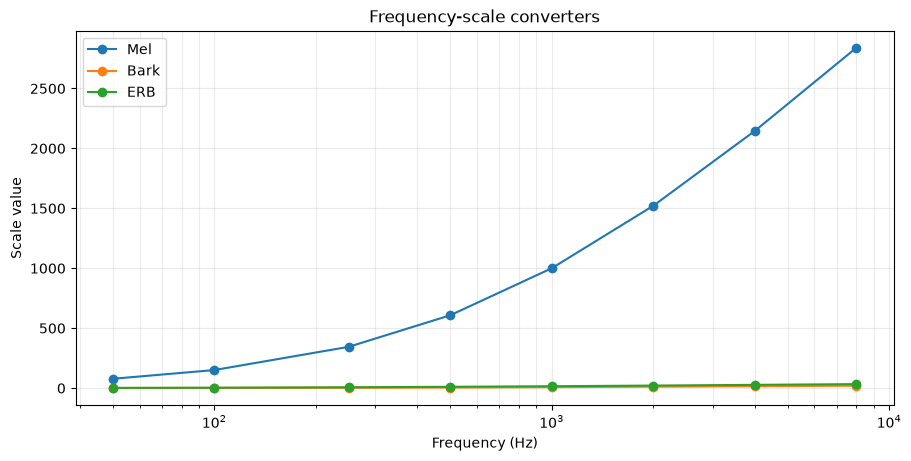

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
ax.plot(freqs, [row[1] for row in rows], marker="o", label="Mel")
ax.plot(freqs, [row[2] for row in rows], marker="o", label="Bark")
ax.plot(freqs, [row[3] for row in rows], marker="o", label="ERB")
ax.set_xscale("log")
ax.set_title("Frequency-scale converters")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Scale value")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()

In [4]:
fs = 16_000
signal = [math.sin(2.0 * math.pi * 440.0 * n / fs) for n in range(fs)]
base = spafe.FeatureOptions(fs=fs, nfft=256, nfilts=24, win_hop=0.02, pre_emph=True)
no_pre = spafe.FeatureOptions(fs=fs, nfft=256, nfilts=24, win_hop=0.02, pre_emph=False)
normalized = spafe.FeatureOptions(
    fs=fs,
    nfft=256,
    nfilts=24,
    win_hop=0.02,
    normalize="mean_variance",
    lifter=-22,
    use_energy=True,
    win_type="blackman",
)
variants = {
    "pre-emphasis": spafe.mfcc(signal, base),
    "no pre-emphasis": spafe.mfcc(signal, no_pre),
    "normalized + liftered": spafe.mfcc(signal, normalized),
}
{name: (len(matrix), len(matrix[0])) for name, matrix in variants.items()}

{'pre-emphasis': (49, 13),
 'no pre-emphasis': (49, 13),
 'normalized + liftered': (49, 13)}

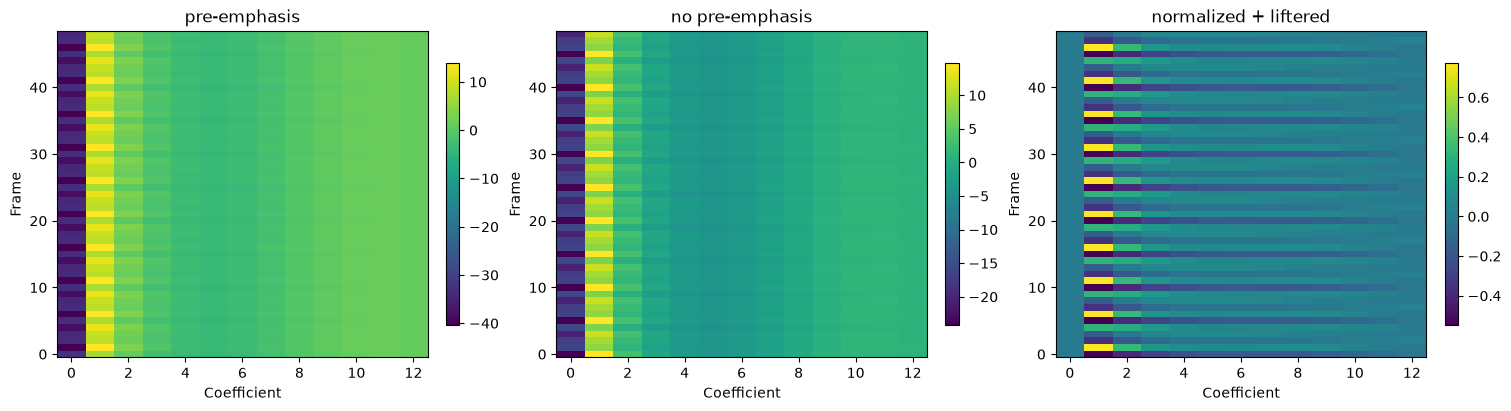

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, (name, matrix) in zip(axes, variants.items()):
    image = ax.imshow(matrix, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(name)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Frame")
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

In [6]:
for scale in ["constant", "ascendant", "descendant"]:
    opts = spafe.FilterBankOptions(nfilts=8, nfft=128, fs=fs, scale=scale)
    bank, _ = spafe.mel_filter_banks(opts)
    print(
        scale,
        "first-row max",
        round(max(bank[0]), 4),
        "last-row max",
        round(max(bank[-1]), 4),
    )

constant first-row max 0.9204 last-row max 0.9998
ascendant first-row max 0.1151 last-row max 0.9998
descendant first-row max 0.9204 last-row max 0.125
